# Transformers

この章では、現代的な自然言語処理（NLP）における重要なアーキテクチャである **トランスフォーマー（Transformers）** について、**自己注意機構（Self-Attention Mechanism）** を中心に解説する。
解きたいタスクに応じて、様々な形で応用されているが、それらに共通する基本的な仕組みを理解することがこの章の目標となる。



## Attention Mechanism (注意機構)

Transformerの中核をなすのが **注意機構（Attention Mechanism）** である。注意機構は、入力データの中で重要な部分に焦点を当てるための仕組みであり、特に自然言語処理においては、文脈情報を効果的に捉えるために利用される。


データの表現方法の章でも少し触れたように、文章中の単語の意味は、その周囲の単語によって大きく影響を受ける。例えば、「bank」という単語は、「river」や「money」といった周囲の単語によって、その意味が「川岸」や「銀行」に変わる。

- ``I sat by the bank of the river.``（私は川の岸辺に座った。）
- ``I went to the bank to deposit some money.``（私はお金を預けるために銀行に行った。）

このような文脈依存性を捉えるために、注意機構は各単語が他の単語に対してどれだけ重要であるかを計算し、その情報を基に重み付けを行う。
ある意味で、単語の意味というのは動的 (dynamic)であって、必ずしも静的(static)なものではないとも言える。

注意機構は、以下の3つの主要なコンポーネントから構成される。

1. **クエリ (Query)**: 注目したい要素を表すベクトル。
2. **キー (Key)**: 各要素の特徴を表すベクトル。
3. **バリュー (Value)**: 実際の情報を含むベクトル。

モデルのbuilding blockであるAttentionレイヤーは、これらのクエリ、キー、バリューを用いて、各要素が他の要素に対してどれだけ注意を払うべきか(どれだけ重要であるか)を計算する。

$$
\begin{align}
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
\end{align}
$$(eq:Attention)

この式は、有名な[Attention is All You Need 論文](https://arxiv.org/abs/1706.03762)で登場する最初の式で、Scaled Dot-Product Attentionと呼ばれるものである。
なお、$d_k$はキーの次元数であり、スケーリングにより勾配消失問題を軽減する役割を果たす。

まずは、この式の意味するところを順を追って説明しよう。
元々が自然言語処理の文脈で提案されたものであるため、多くの論文・書籍なども文章を例にして説明している。
筆者のように、自然言語処理のバックグラウンドを持たない人にとっては、トークンなどの用語が出てきて面食らってしまうことも多いように思う。そこで、ここではあえて「ラーメン愛好家のラーメン採点」という例を用いて説明することにする。その後、抽象的なベクトルデータを例にしてより一般的な説明を行う。


`````{admonition} ラーメン愛好家のラーメン採点
:class: tip

Aさんはラーメン愛好家であり、様々なラーメン店を訪れては、その味を日々採点している。Aさんは、ラーメンを幾つかの項目で数値化して記録している。
例えば、`スープの系統(醤油、味噌、塩、豚骨など)`, `価格`, `麺の量`, `提供スピード`, `麺の太さ`, `トッピングの豊富さ`, `店の雰囲気`などである。ただし、Aさんは自分自身が、ラーメンの評価、いわば **総得点** を、それらの項目の単純な和ではなく、もっと複合的に評価していることに気づいた。以来、ラーメン以外の要素、例えば`その日の天気`や`昼に行った運動の有無`、`前日の睡眠時間`なども、つぶさに記録を残すようにした。

このことから、ラーメンの総得点は、各項目の評価点の単純な総和ではなく、Aさん自身も言語化できない複雑な基準に基づいて決定されていることになる。
Aさんのラーメン記録はブログにまとめられており、次に訪れる予定のラーメン店のリストも公開されている。このブログを偶然訪問したBさんは、Aさんの過去のラーメン記録を分析し、次にAさんがブログを更新した際、記事の途中にある項目の評価点から、総得点を予測する遊びを考えた。Bさんは、以下のようにモデルを構築・訓練していく。

1. これまでのラーメン記録に基づいて、各項目の評価点をベクトルとして表現する。
2. Aさんが今後更新するブログに記載される新たなラーメン店の(総得点以外の)項目を **クエリ/query (Q)** として使用する。
3. これまでのラーメン記録の各項目の評価点を **キー/key (K)** として使用し、総得点を **バリュー/value (V)** として使用する。
4. 新たなラーメンのクエリに対して、過去のラーメン記録のキーとの **類似度** を計算し、その類似度に基づいてバリューを重み付けして総得点を予測する。その際、類似度の計算にはドット積(内積)を用い、重み付けにはソフトマックス関数を用いて重みの正規化を行う。
`````

上で示したクエリ・キー・バリューを用いた計算がまさにAttentionの計算式である。
簡単のために、$\sqrt{d_k}$によるスケーリングは無視するとして図示してみよう。

```{image} pic/attention.png
:width: 600px
:align: center


```

繰り返しになるが、必要な操作は、クエリとキーの内積を計算しソフトマックス関数で正規化し、その重みをバリューにかけることである。
$\cdot, \times, +$ はそれぞれ内積、積、和という操作を適応することを表している。

内積を計算する以上、クエリとキーは同じ次元数である必要があることを覚えておこう。
また、上ではクエリが1つ、キーとバリューが複数ある場合を示したが、クエリが複数ある場合や、バリューが多次元の場合も同様に計算できる。

### 一般的なベクトルデータへの拡張

上で示したラーメン採点の例は、Attentionの計算をイメージしやすくするためのものである。実際には、自然言語処理に限らず、様々なベクトルデータに対してAttentionの計算を適応できる。そこで、もう少し一般的なベクトルデータを例にして説明しよう。

:::{margin}
ただし、量子系の場合はベクトルの要素が複素数になる場合がある。
そうした場合は、実部と虚部を分けて2倍の次元数の実数ベクトルにするなどの方法が考えられる。
:::
それぞれのドメインのデータがどんな構造であるかはさておき、方法さえ決めてしまえば、データを数値のベクトルに変換することはいつでも可能である。例えば画像であれば、ピクセル値を並べたベクトルに変換できるし、音声であれば、時間領域の波形データをフーリエ変換して周波数領域のスペクトルに変換し、そのスペクトルをベクトルとして扱うことができる。量子系の状態に興味があるのなら、それぞれの状態に対応するベクトルを用意すればよい。
テキスト処理の場合も同様で、単語や文をベクトルとして表現する方法がいくつも提案されている。


このように、データをベクトルとして表現できると仮定して、これから実現したいことは、
「入力データの中で、特に重要な要素に焦点を当てること」 あるいは成分間の「関連性を捉えること」である。

画像であれば、隣あうピクセル同士の関連性が高いことが多いし、音声であれば、時間的に近いサンプル同士の関連性が高かったり、周期性があったりする。
量子系の状態であれば、特定の成分間に相関や対称性があることが多い。テキスト処理であれば、文脈的に近い単語同士の関連性が高いことが多い。

クエリ、キー、バリューをそれぞれ以下のように定義する。

$$
Q \in \mathbb{R}^{m \times d_k}, \quad K \in \mathbb{R}^{n \times d_k}, \quad V \in \mathbb{R}^{n \times d_v}
$$

ここで、$m$はクエリの数、$n$はキーとバリューの数、$d_k$はキーとクエリの次元数、$d_v$はバリューの次元数を表す。
上で見たラーメンの例では、$m=1$, $n$は過去のラーメン記録の数、 $d_k$は記録の項目の数、$d_v=1$ (総得点) であった。

Attentionの計算を再掲すると

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

Softmax関数は行ごとに適応されるため、$QK^T$の各行はそれぞれのクエリに対応するキーとの類似度を表していることになる。
最終的な出力は、各クエリに対して、キーとの類似度に基づいて重み付けされたバリューの和となり、その形状は $(m, d_v)$ となる。
上では、クエリが入力、キーとバリューは過去の記録であったが、クエリ、キー、バリューは同じデータから生成されることも多い。例えば、自然言語処理においては、入力された文章の単語をベクトル化して、それをクエリ、キー、バリューのそれぞれに線形変換して生成することが一般的である。
このようにクエリ、キー、バリューを同じ入力から生成する場合は、**自己注意機構 (Self-Attention Mechanism)** と呼ばれる。

$$
\begin{align}
Q &= XW^Q \\
K &= XW^K \\
V &= XW^V
\end{align}
$$

ここで、$X$は入力データのベクトル表現、$W^Q, W^K, W^V$はそれぞれクエリ、キー、バリューを生成するための重み行列である。
上のラーメンの例では、クエリは新たなラーメンの項目の評価点、キーは過去のラーメン記録の項目の評価点、バリューは過去のラーメン記録の総得点であり、予め決められたベクトル値であったが、上のような線形変換を入れることで、クエリ、キー、バリューを入力データから動的に生成することができるようになる。
この重み行列を、学習可能なパラメータとして、モデルの訓練を通じて最適化していくことを考えると、ニューラルネットワークとしてのAttentionレイヤーの構造が見えてくるだろう。


## スケーリングの必要性

Attentionの計算式におけるスケーリング項 $\frac{1}{\sqrt{d_k}}$ は、クエリとキーの内積が大きくなりすぎることを防ぐために導入されている。内積が大きくなると、ソフトマックス関数の出力が極端になり、勾配消失問題が発生しやすくなる。この問題を軽減するために、内積をキーの次元数の平方根で割ることで、内積の値を適切な範囲に抑える(スケールする)ことができる。

ニューラルネットワークにしばし、正規化レイヤーが用いられるが、これは入力の値を適切な範囲に抑えることで、学習の安定性を向上させることにある。スケーリングも同様の目的で導入されていると考えることができる。

<BarContainer object of 40 artists>

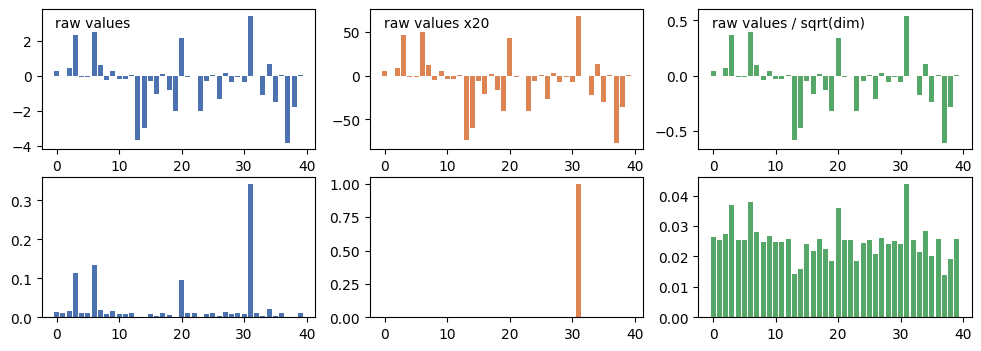

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
cols = sns.color_palette("deep")

np.random.seed(42)
dim = 40
x = np.random.randn(dim) 
x = np.sign(x) * np.abs(x)**2 
y = 20 * x
z = x / np.sqrt(dim)
xp = np.arange(dim)

softmax_x = np.exp(x) / np.sum(np.exp(x))
softmax_y = np.exp(y) / np.sum(np.exp(y))
softmax_z = np.exp(z) / np.sum(np.exp(z))
plt.figure(figsize=(12, 4))
axs = [ plt.subplot(2, 3, i+1) for i in range(2*3) ]

# plow raw values in upper panels
axs[0].bar(xp, x, color=cols[0]); axs[0].text(0.05, 0.9, "raw values", transform=axs[0].transAxes, ha="left", va="center")
axs[1].bar(xp, y, color=cols[1]); axs[1].text(0.05, 0.9, "raw values x20", transform=axs[1].transAxes, ha="left", va="center")
axs[2].bar(xp, z, color=cols[2]); axs[2].text(0.05, 0.9, "raw values / sqrt(dim)", transform=axs[2].transAxes, ha="left", va="center")

# plot softmax values in lower panels
axs[3].bar(xp, softmax_x, color=cols[0])
axs[4].bar(xp, softmax_y, color=cols[1])
axs[5].bar(xp, softmax_z, color=cols[2])

上の図では、それぞれ適当な乱数で生成したベクトル値(青)、それを20倍したもの(橙)、スケーリングしたもの(緑)の値と、それぞれをsoftmax関数に通した後の値を示している。
softmax関数は指数関数の性質により、入力の値が大きくなると出力が極端になりやすい。スケーリングによって、内積の値を適切な範囲に抑えることで、softmaxの出力が極端になるのを防ぎ、勾配消失問題を軽減することができる。

## マスク

言語モデルなどのタスクでは、入力の一部をマスクする必要がある場合がある。例えば、次の単語を予測するタスクでは、未来の単語を見ることができない。
そうした状況下で、続く単語を予測する際に、未来の単語に対応するAttentionの値を0にするマスクを適用する。

マスクは、Attentionの計算において、特定の位置の類似度を無限小にすることで、ソフトマックス関数の出力が0になるようにする。
これにより、マスクされた位置の情報がAttentionの出力に影響を与えないようにすることができる。
実装上は、Softmax関数を適応する前に$-\infty$を加えることでmaskを実現することができる。





## 位置エンコーディング (Positional Encoding)

上のマスクとは別に、入力の位置情報(テキストであれば、単語の順序)をモデルに提供するために、位置エンコーディングが用いられる。
ここまでの説明では、入力の位置情報を明示的に考慮してこなかったが、Transformerは入力の位置情報を考慮するために、位置エンコーディングを用いている。

:::{margin}
願わくば２つの文章ともに真であってほしいが
:::
そうしなければ例えば以下の2つの文は、単語の順序が異なるだけで同じ意味を持つとモデルが誤認してしまう可能性がある。

- ``John loves Mary.``（ジョンはメアリーを愛している。）
- ``Mary loves John.``（メアリーはジョンを愛している。）

位置エンコーディングに対しては様々な方法が提案されているが、Transformerの元論文では、以下のような正弦波と余弦波を用いた位置エンコーディングが採用されている。

$$
\begin{align}
PE_{(pos, 2i)} &= \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right) \\
PE_{(pos, 2i+1)} &= \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)
\end{align}
$$

ここで、$pos$は位置を表す整数、$i$は(embedding)ベクトルのインデックス、$d_{model}$はモデルの次元数(埋め込みベクトルの次元数)を表す。
10000という数は、位置エンコーディングの周期を調整するためのものであり、モデルの次元数に応じて適切な値が選ばれている。

$\sin, \cos$を用いることで
- 出力が (-1, 1) の範囲に収まる: これは、モデルの学習を安定させるために重要である。
- 異なる位置 $pos$ に対して異なるエンコーディングを生成する: モデルが位置情報を区別できる。
- 位置$n$と位置$n+k$のエンコーディングの類似度が、$k$に依存する: これにより、モデルが相対的な位置関係を学習できる。

## Multi-Head Attention

件の[論文](https://arxiv.org/abs/1706.03762)でも提案されているように、Attentionの計算を並列化することで、モデルが効果的に複数の異なる視点から入力データを捉えることができるようになる。これが **Multi-Head Attention** と呼ばれるものである。

:::{margin}
簡単のため、maskは省略した。
:::
Multi-Head Attentionでは、クエリ、キー、バリューを複数のヘッドに分割して、それぞれのヘッドで独立してAttentionの計算を行う。これまでの式に基づいて、Multi-Head Attentionの計算を表すと以下のようになる。

$$
\begin{align}
\text{MultiHead}(x)
& = \text{Concat}(\text{head}_1, \text{head}_2, \ldots, \text{head}_h)W^O \\
\text{where} \quad \text{head}_i
& = \text{Attention}(xW_i^Q, xW_i^K, xW_i^V)
\end{align} 
$$

上では、$h$はヘッドの数を表し、$W_i^Q, W_i^K, W_i^V$はそれぞれのヘッドに対応するクエリ、キー、バリューを生成するための重み行列である。各ヘッドで計算されたAttentionの出力を連結して、それにさらに重み行列$W^O$をかけることで、最終的なMulti-Head Attentionの出力が得られる。

## Transformerの構造

ここまでで、Transformerの中核をなすAttention機構と必要な演算についてその概要を説明してきた。
以下では、Transformerの基本的な構造について説明する。
Transformerは、エンコーダーとデコーダーの2つの主要なコンポーネントから構成されている。

対象とするデータは、例えば自然言語処理における単語列や文章列などが想定されるが、ここでは、テキストをベクトルに変換する方法の詳細には立ち入らず、ベクトルデータが与えられたと仮定して説明を進める。
上で用意したAttentionブロックはしばし、skip connectionを伴い、Feed Forward Neural Network (FFNN)と組み合わせて、以下のような構造を持つことが多い。

```{image} pic/Sketch_Transformer.png
:width: 600px
:align: center

```

skip connectionは、ResNetなどのネットワークで提案された構造で、入力を迂回して出力に直接加えることで、勾配消失問題を軽減し、学習を安定させる効果がある。
FFNNは、Attentionの出力をさらに処理するためのもので、通常のMLPなどが用いられる。
さらに、加算された出力に対して、Layer Normalizationが適応されることも多い。これは、Attentionの出力やFFNNの出力が適切な範囲に収まるように正規化することで、やはりこれも学習の安定性を向上させる効果が期待される。

こうした構造を持つAttentionブロックを複数積み重ねることで、Transformerのエンコーダーやデコーダーが構成され、Transformerベースのモデルが構築される。


```{image} pic/Fig1_1706.03762.png
:width: 300px
:align: center

```

上に示したのは、Transformerの元論文である[Attention is All You Need](https://arxiv.org/abs/1706.03762)のFigure 1である。
左側がエンコーダー、右側がデコーダーである。言語をトークン化する部分などはこの資料では説明していないが、エンコーダーとデコーダーの構造は、上で説明したAttentionブロックを複数積み重ねたものであることがわかるだろう。

## その他の話題

### Tokenization

自然言語処理を行う際のデータ単位として、最も適切なものはなんだろうか？

まず考えつくのが、文章を単語に分割するというものだ。ただし、用意に考えると分かるように日本語のような言語は単語への分割が容易ではない。というのも英語の文章のように明確に単語単位に分かれておらず、文脈がないと単語の分割にambiguityが生じてしまうケースがあるからだ。

「くるまでまっているね」と書かれていても「車で待っているね」なのか「来るまで待っているね」なのかは前後の文脈を見るまでわからない。

では、対極的な方法として、文字を単位にすることを考えてみる。だが、これもおそらくあまり有効ではないだろう。
というのも、それぞれの文章が持つ構造や文法などの意味に注目した単位になっていないからだ。
また、単語や文字の埋め込みベクトルを同じ次元で考えるとすると、単語を単位として考えるのに比べて、文字単位での情報処理は明らかに保持すべき情報のサイズが大きくなり非効率になる。

そこで、トークン (token)と呼ばれる概念が登場し、自然言語をトークンに変換することをTokenizationと呼ぶ。
単語レベルで扱う場合、文字レベルで扱う場合のそれぞれの利点を活かしつつ、もう少し柔軟な数値表現の単位(unit)を構成しよう、というのが基本的なアイデアである。

トークンは、単語の一部であったり、複数の単語をまとめたものであったりすることがある。
例えば、「unhappiness」という単語は、「un-」という接頭辞、「happi」という語幹、「-ness」という接尾辞に分割されることがある。これらの部分をそれぞれトークンとして扱うことで、モデルがより細かいレベルで言語の構造を捉えることができるようになる。

実際の実装では、Byte Pair Encoding (BPE) や WordPiece などのアルゴリズムが用いられて、トークンの分割が行われることが多い。
自然言語処理に興味がある人はこれらに関する文献を参照してみるとよいだろう。

この章の説明では、transformerの内部で処理されるデータはベクトルデータである、という以外の説明をしていない。
実際の自然言語処理の文脈においては、単語レベルの埋め込みベクトルではなく、トークンに対応するベクトルを操作していることが多いことは覚えておいてもよいだろう。


### Transformerの利点と応用先

TransformerやAttention機構の利点は、入力データの中で重要な要素に焦点を当てることができる点にある。これにより、モデルが文脈情報を効果的に捉えることができるようになる。
また、Transformerは並列化が容易であるため、大規模なデータセットを効率的に処理することができる。さらに、Transformerは、自然言語処理だけでなく、画像処理や音声処理など、様々なドメインのタスクに応用されている。

Transformerはその後の研究で、モデルサイズ・データセットを増大させることに伴う性能向上がべき乗的であることが示されており、 **スケーリング則(Scaling Laws)** と呼ばれる現象が観察されている。
性能向上がべき乗であることは、投資に対するリターンが大きいことを意味するため、企業がこぞってTransformerベースのモデルの開発に投資している理由の一つである。
(少なくとも現状は)頭打ちになることはなく、実質的に資本力のある企業にしか実装できないような巨大なモデルが次々と登場しているが、今後もこの傾向が続くのか、さらに効率のよいモデルが登場するのか、興味深いところである。